<a href="https://colab.research.google.com/github/Atash22/lab_works/blob/main/classification_and_localization_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification and Localization with Xception

**Lab 4 — Advanced Applied Mathematical Concepts for Deep Learning**



## Step 1 — Imports and setup

In [1]:
!pip install -q -U tensorflow_datasets

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np



tf.random.set_seed(42)  # for reproducibility

## Step 2 — Load the dataset

We split `tf_flowers` into train (70%), validation (15%), and test (15%) sets.

In [3]:
# The 'AttributeError' is due to an incompatible protobuf version detected during initial imports.
# This specific conflict cannot be resolved by 'pip install' in the same session without a restart.
# Installing protobuf==6.31.1 to match the required gencode version from tensorflow_metadata.
# >>> IMPORTANT: You MUST restart the Colab runtime after running this cell. <<<
!pip install protobuf==6.31.1

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples  # 3670 images
n_classes = info.features["label"].num_classes    # 5 flower classes
class_names = info.features["label"].names

print(f"Dataset size: {dataset_size} images")
print(f"Number of classes: {n_classes} -> {class_names}")

train_set_raw, valid_set_raw, test_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
    as_supervised=True)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.OQW1L1_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Dataset size: 3670 images
Number of classes: 5 -> ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


## Step 3 — Preprocess images and create labels

Each image is resized to 224x224 and preprocessed for Xception. Each example returns:
- the processed image
- a tuple of `(class_label, bounding_box)`

The bounding box here is a **fixed simulated box** `[x_min, y_min, x_max, y_max]` covering the center 50% of the image.

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):
    resized_image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    final_image = tf.keras.applications.xception.preprocess_input(resized_image)

    # Simulated bounding box: center box covering 50% of the image
    fake_box = tf.constant([0.25, 0.25, 0.75, 0.75])  # [x_min, y_min, x_max, y_max]

    return final_image, (label, fake_box)

train_set = (train_set_raw
             .shuffle(1000)
             .repeat()
             .map(preprocess)
             .batch(BATCH_SIZE)
             .prefetch(1))

valid_set = (valid_set_raw
             .map(preprocess)
             .batch(BATCH_SIZE)
             .prefetch(1))

test_set = (test_set_raw
            .map(preprocess)
            .batch(BATCH_SIZE)
            .prefetch(1))

## Step 4 — Build the model

We load **Xception** pretrained on ImageNet as a feature extractor (`include_top=False` removes its original
classification head). On top of the shared feature vector, we attach **two separate output heads**:

- `class_output`: predicts the flower class (softmax over `n_classes`)
- `loc_output`: predicts the bounding box (4 raw numbers)

Both heads share the same backbone features — this is the "shared computation" idea used in detectors
like Faster R-CNN, applied here in a simpler single-object setting.

In [5]:
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                       include_top=False)

avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

class_output = tf.keras.layers.Dense(n_classes, activation="softmax", name="class_output")(avg)
loc_output = tf.keras.layers.Dense(4, name="loc_output")(avg)  # bounding box: 4 numbers

model = tf.keras.Model(inputs=base_model.input,
                        outputs=[class_output, loc_output])

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, None,      │        864 │ input_layer[0][0] │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, None,      │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, None,      │          0 │ block1_conv1_bn[… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, None,      │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, None,      │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, None,      │          0 │ block1_conv2_bn[… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, None,      │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, None,      │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, None,      │          0 │ block2_sepconv1_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, None,      │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, None,      │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │      8,192 │ block1_conv2_act… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, None,      │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ block2_pool[0][0… │
│                     │ None, 128)        │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, None,      │          0 │ add[0][0]       

 Total params: 20,879,921 (79.65 MB)

 Trainable params: 20,825,393 (79.44 MB)

 Non-trainable params: 54,528 (213.00 KB)

## Step 5 — Freeze the backbone (transfer learning, phase 1)

Since Xception is pretrained, we first **freeze its layers** and only train the two new output heads.
This is standard practice for fine-tuning: train the new layers first so their random initial weights
don't send large, disruptive gradients back through the pretrained backbone.

In [6]:
for layer in base_model.layers:
    layer.trainable = False

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

model.compile(loss=["sparse_categorical_crossentropy", "mse"],
              loss_weights=[0.8, 0.2],  # prioritize classification over (simulated) box
              optimizer=optimizer,
              metrics={"class_output": "accuracy"})

## Step 6 — Train phase 1 (frozen backbone)

In [7]:
history = model.fit(train_set,
                     steps_per_epoch=int(0.7 * dataset_size / BATCH_SIZE),
                     validation_data=valid_set,
                     epochs=5)

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 66s 359ms/step - class_output_accuracy: 0.7605 - class_output_loss: 0.6496 - loc_output_loss: 0.1006 - loss: 0.5398 - val_class_output_accuracy: 0.8693 - val_class_output_loss: 0.3668 - val_loc_output_loss: 0.0655 - val_loss: 0.3127
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - class_output_accuracy: 0.8727 - class_output_loss: 0.3655 - loc_output_loss: 0.0563 - loss: 0.3037 - val_class_output_accuracy: 0.8929 - val_class_output_loss: 0.3381 - val_loc_output_loss: 0.0502 - val_loss: 0.2897
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step - class_output_accuracy: 0.8984 - class_output_loss: 0.3046 - loc_output_loss: 0.0447 - loss: 0.2526 - val_class_output_accuracy: 0.9002 - val_class_output_loss: 0.2781 - val_loc_output_loss: 0.0426 - val_loss: 0.2361
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 159ms/step - class_output_accuracy: 0.9129 - class_output_loss: 0.2713 - loc_output_loss: 0.0372 - loss: 0.2245 - val_class_output_accuracy: 0.9093 -

## Step 7 — Fine-tune (phase 2)

Now we **unfreeze the backbone** and continue training with a much smaller learning rate.
This lets Xception's pretrained features adjust slightly to better fit the flower dataset,
without a large learning rate destroying what it already learned from ImageNet.

In [8]:
for layer in base_model.layers:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

model.compile(loss=["sparse_categorical_crossentropy", "mse"],
              loss_weights=[0.8, 0.2],
              optimizer=optimizer,
              metrics={"class_output": "accuracy"})

history_fine = model.fit(train_set,
                          steps_per_epoch=int(0.7 * dataset_size / BATCH_SIZE),
                          validation_data=valid_set,
                          epochs=5)

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 96s 621ms/step - class_output_accuracy: 0.8383 - class_output_loss: 0.5519 - loc_output_loss: 0.0616 - loss: 0.4538 - val_class_output_accuracy: 0.9056 - val_class_output_loss: 0.2679 - val_loc_output_loss: 0.1202 - val_loss: 0.2465
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 546ms/step - class_output_accuracy: 0.9090 - class_output_loss: 0.3341 - loc_output_loss: 0.0471 - loss: 0.2767 - val_class_output_accuracy: 0.9129 - val_class_output_loss: 0.2450 - val_loc_output_loss: 0.0714 - val_loss: 0.2169
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 544ms/step - class_output_accuracy: 0.9383 - class_output_loss: 0.2514 - loc_output_loss: 0.0439 - loss: 0.2099 - val_class_output_accuracy: 0.9165 - val_class_output_loss: 0.2371 - val_loc_output_loss: 0.0495 - val_loss: 0.2049
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 542ms/step - class_output_accuracy: 0.9539 - class_output_loss: 0.1968 - loc_output_loss: 0.0418 - loss: 0.1658 - val_class_output_accuracy: 0.9201 -

## Step 8 — Evaluate on the test set

In [9]:
results = model.evaluate(test_set)
print("Test results:", results)

18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - class_output_accuracy: 0.9055 - class_output_loss: 0.2501 - loc_output_loss: 0.0457 - loss: 0.2093
Test results: [0.20934045314788818, 0.2500869333744049, 0.04567386582493782, 0.9054545164108276]


## Step 9 — Visualize predictions

Let's look at a few test images with the predicted class and predicted bounding box drawn on top,
so we can see the model's output directly rather than just numbers.

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


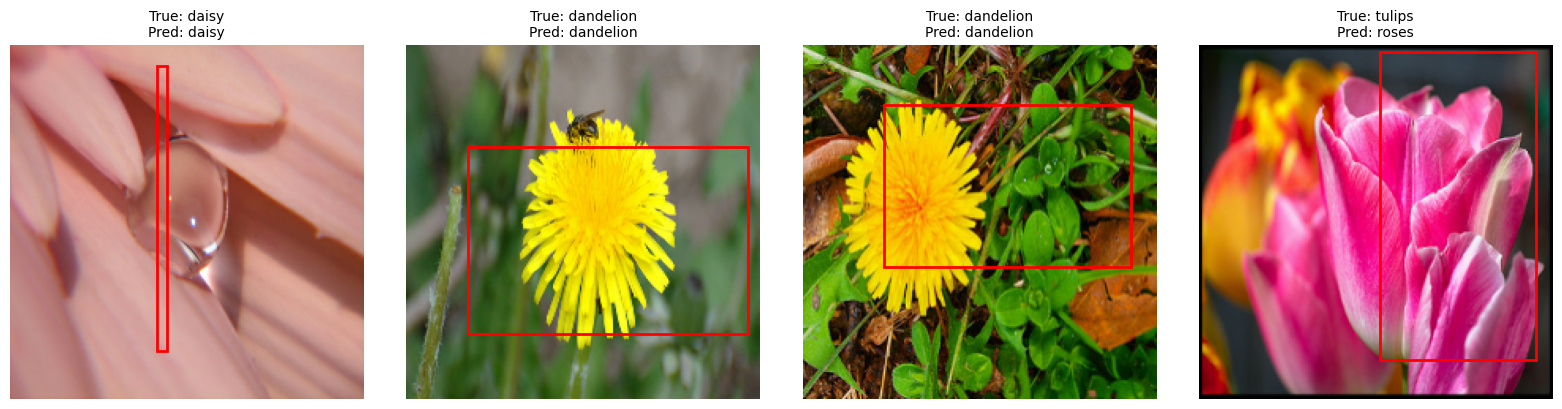

In [10]:
import matplotlib.patches as patches

def unprocess_image(img):
    # reverse Xception preprocessing roughly for display purposes
    img = img.numpy()
    img = (img + 1) / 2.0  # xception preprocess_input scales to [-1, 1]
    return np.clip(img, 0, 1)

# grab one batch of test images
for images, (labels, boxes) in test_set.take(1):
    preds_class, preds_box = model.predict(images)
    break

n_show = 4
fig, axes = plt.subplots(1, n_show, figsize=(16, 4))

for i in range(n_show):
    ax = axes[i]
    img = unprocess_image(images[i])
    ax.imshow(img)

    h, w = img.shape[0], img.shape[1]
    x_min, y_min, x_max, y_max = preds_box[i]
    rect = patches.Rectangle(
        (x_min * w, y_min * h),
        (x_max - x_min) * w,
        (y_max - y_min) * h,
        linewidth=2, edgecolor="red", facecolor="none")
    ax.add_patch(rect)

    true_class = class_names[labels[i].numpy()]
    pred_class = class_names[np.argmax(preds_class[i])]
    ax.set_title(f"True: {true_class}\nPred: {pred_class}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Summary

- **Backbone:** Xception, pretrained on ImageNet, used as a shared feature extractor.
- **Two output heads:** a classification head (softmax over 5 flower classes) and a localization
  head (4 numbers for a bounding box), both branching from the same pooled feature vector.
- **Two-phase fine-tuning:** first train only the new heads with the backbone frozen, then unfreeze
  the backbone and continue training at a lower learning rate.
- **Limitation:** the bounding boxes used here are simulated (a fixed centered box), since `tf_flowers`
  has no real localization labels. The classification results are meaningful; the box regression results
  are purely illustrative of the architecture and training mechanics, not a real localization result.